# Mapping the Ecolizer with a variational autoencoder

**Ecodesign course, ISAE-SUPAERO** · companion notebook of the Distill article *"Mapping the Ecolizer"*

The [OVAM Ecolizer 2.0](https://www.ovam.be/ecolizer) is a booklet of environmental indicators for about 60 families of materials,
processes and energy carriers. One number summarises each entry: the **eco-indicator in millipoints (mPt)**, where
1 Pt is one thousandth of the yearly environmental burden of an average European and the weighting of the ReCiPe damage categories is
*human health 400 : ecosystems 400 : raw materials 200*. Lower is better, and only **relative** comparisons are meaningful.

In this notebook we

1. load the tables that were extracted from the PDF (`data/*.csv`) and look at them with ordinary plots,
2. turn the **eco-Ashby indices** of the previous lecture (impact per unit of stiffness-limited function) into numbers,
3. train a small **variational autoencoder (VAE)** that learns a 2-D map of the materials from their eco-profile *and* their typical density and stiffness,
4. use the decoder as a continuous surface: colour the map by any property, draw contours of an eco-index, and run a **gradient search** for low-impact "materials",
5. test honestly what the VAE can and cannot do, and export everything the interactive article needs.

> **What is from the PDF and what is not.** Production, recycling and waste-treatment indicators, and all processing, energy and transport numbers
> come from the Ecolizer. **Density ρ and Young's modulus E are not in the PDF**: they are typical handbook values, rounded, added by us
> (column `props_approx = 1`). Wood panels, which the PDF gives per m³, were converted to mPt/kg with an assumed density (`unit_conversion`).
> The steel sheet (p. 22 of the booklet) is a raster image and was typed in by hand.

In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch, torch.nn as nn
warnings.filterwarnings("ignore", category=UserWarning)

torch.set_num_threads(2)
DATA = "../data"            # run the notebook from the notebook/ folder
EXPORT = "../data"          # where the interactive article reads its JSON

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "font.size": 10, "axes.titlesize": 11})
FAMILIES = ["Ferrous metals", "Non-ferrous metals", "Precious & critical metals", "Thermoplastics", "Composites & thermosets", "Elastomers",
            "Bio-based plastics", "Recycled plastics", "Wood & panels", "Paper & board", "Glass & ceramics", "Minerals & cement", "Insulation", "Chemicals & glues"]
PAL = dict(zip(FAMILIES, ["#5B6770", "#2A6FB0", "#7A4FA3", "#E2924A", "#9A3A2F", "#C97A97", "#97A02A", "#6F8F3A", "#8C6248", "#B8A27A", "#2FA3AD", "#8C8A84", "#D8B13E", "#444444"]))
mat = pd.read_csv(f"{DATA}/ecolizer_materials.csv")
print(mat.shape)
mat.head()

(193, 13)


,name,family,subfamily,page,prod,rec_proc,rec_saved,rec_total,waste,rho,E,props_approx,unit_conversion
0,Cast iron,Ferrous metals,Iron,24,173.0,76.0,-173.0,-97.0,26.0,7100.0,170.0,1,NaN
1,Stainless steel 18/8 (primary),Ferrous metals,Stainless steel,25,551.0,76.0,-551.0,-475.0,26.0,7900.0,195.0,1,NaN
2,"Stainless steel 18/8 (secondary, electric)",Ferrous metals,Stainless steel,25,511.0,NaN,NaN,NaN,26.0,7900.0,195.0,1,NaN
3,"Steel, low-alloyed (converter)",Ferrous metals,Steel,26,231.0,76.0,-231.0,-155.0,26.0,7850.0,210.0,1,NaN
4,"Steel, un-alloyed (converter)",Ferrous metals,Steel,26,165.0,NaN,NaN,NaN,26.0,7850.0,210.0,1,NaN


## 1 · The data

Each row is one material variant with its indicators in **mPt per kg**:

| column | meaning |
|---|---|
| `prod` | production (cradle to gate) |
| `rec_proc` | impact of the recycling process itself (only where the booklet gives a full recycling block) |
| `rec_saved`, `rec_total` | credit for the primary material that is *not* produced, and the net total (`rec_proc + rec_saved`) |
| `waste` | EU waste-treatment scenario (80 % landfill, 20 % incineration) |
| `rho`, `E` | typical density (kg/m³) and Young's modulus (GPa), **not from the PDF** |

Missing values (`dna` in the booklet, or simply not applicable) are `NaN`. A VAE can deal with that, as we will see.

In [2]:
summary = (mat.groupby("family")
             .agg(n=("name", "count"), prod_median=("prod", "median"), prod_min=("prod", "min"), prod_max=("prod", "max"),
                  n_waste=("waste", "count"), n_recycling=("rec_proc", "count"), n_rho_E=("E", "count"))
             .reindex(FAMILIES))
summary.round(1)

,n,prod_median,prod_min,prod_max,n_waste,n_recycling,n_rho_E
family,,,,,,,
Ferrous metals,9,231.0,61.0,1105.0,9,5,7
Non-ferrous metals,15,646.0,45.0,3768.0,9,5,12
Precious & critical metals,7,1163775.0,63042.0,9558421.0,0,0,6
Thermoplastics,24,396.0,220.0,16929.0,24,10,19
Composites & thermosets,14,552.0,264.0,1249.0,14,0,13
Elastomers,6,399.5,230.0,599.0,6,0,6
Bio-based plastics,2,293.5,275.0,312.0,0,0,2
Recycled plastics,6,78.5,62.0,95.0,0,0,0
Wood & panels,17,223.6,58.6,558.0,17,0,17


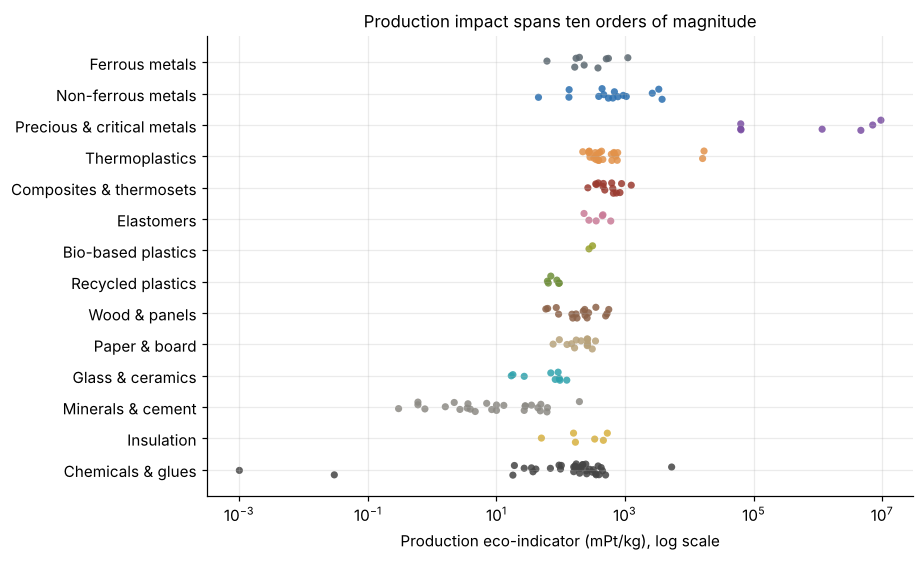

Range: 0.001 to 9,558,421 mPt/kg


In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for i, f in enumerate(FAMILIES[::-1]):
    d = mat[mat.family == f]
    ax.scatter(d["prod"], np.full(len(d), i) + np.random.default_rng(i).uniform(-.18, .18, len(d)), s=22, color=PAL[f], alpha=.85, edgecolor="none")
ax.set_xscale("log"); ax.set_yticks(range(len(FAMILIES))); ax.set_yticklabels(FAMILIES[::-1])
ax.set_xlabel("Production eco-indicator (mPt/kg), log scale"); ax.set_title("Production impact spans ten orders of magnitude")
plt.tight_layout(); plt.show()
print("Range:", mat['prod'].min(), "to", f"{mat['prod'].max():,.0f}", "mPt/kg")

Ten decades (from tap water at 0.03 mPt/kg to rhodium at 10⁷). A single linear axis is useless, so we work with **log₁₀** of every positive quantity from now on.
Three groups stand out: precious and critical metals (platinum-group metals and mercury, 10⁴–10⁷ mPt/kg), engineering plastics and metals
(10²–10³), and minerals, wood and paper (10⁰–10²).

### Production versus waste treatment

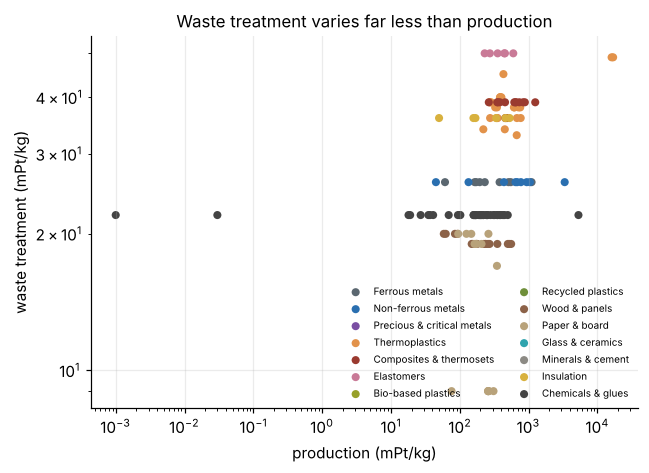

Spearman rank correlation, production vs waste: 0.5


In [4]:
d = mat.dropna(subset=["waste"])
fig, ax = plt.subplots(figsize=(6, 4.4))
for f in FAMILIES:
    g = d[d.family == f]
    ax.scatter(g["prod"], g["waste"], s=28, color=PAL[f], label=f, edgecolor="none")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("production (mPt/kg)"); ax.set_ylabel("waste treatment (mPt/kg)")
ax.legend(fontsize=6.5, ncol=2, frameon=False, loc="lower right"); ax.set_title("Waste treatment varies far less than production")
plt.tight_layout(); plt.show()
print("Spearman rank correlation, production vs waste:", round(d["prod"].corr(d["waste"], method="spearman"), 2))

The waste indicator moves within a narrow band (roughly 9–50 mPt/kg, rank correlation with production only about 0.5) whereas production spans many decades. For most materials
**production dominates the burden of the material phase**; only for low-impact, high-volume materials (wood, minerals) does the
end of life matter.

### How much of the production impact can recycling win back?

`rec_gain = −rec_total / prod` is the fraction of the production impact that is avoided when the material is recycled in a closed loop
(it is 1 if the recycling process itself were free and 0 if it cancelled the credit). Only 21 entries have the full block.

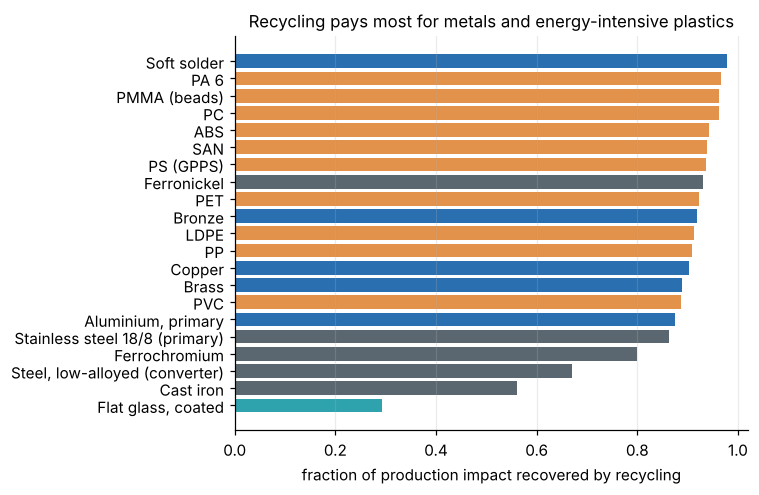

In [5]:
mat["rec_gain"] = (-mat["rec_total"] / mat["prod"]).clip(0, 1)
r = mat.dropna(subset=["rec_gain"]).sort_values("rec_gain")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(r["name"], r["rec_gain"], color=[PAL[f] for f in r["family"]])
ax.set_xlabel("fraction of production impact recovered by recycling"); ax.set_xlim(0, 1.02); ax.grid(axis="y", alpha=0)
ax.set_title("Recycling pays most for metals and energy-intensive plastics")
plt.tight_layout(); plt.show()

## 2 · Eco-Ashby indices

In the lecture, price on the Ashby chart was replaced by the **eco-cost per volume**. The Ecolizer lets us do the same with eco-indicators.
For a part that must meet a given stiffness, the impact is `production × mass`, and the mass of the lightest part is proportional to
`ρ / E^a` with `a = 1, 1/2, 1/3` for a tie, a beam and a panel. So the quantity to **minimise** is

$$ I_a \;=\; \frac{\text{prod}\cdot\rho}{E^{\,a}} \qquad \text{[mPt per unit of structural function, up to a geometry constant]} $$

and on a log–log chart of eco-cost per volume against E the contour `I_a = const` is a straight line of slope `a`.

In [6]:
eng = mat.dropna(subset=["rho", "E"]).copy()          # the "engineering set" used for the VAE below
print(len(eng), "materials with density and modulus (typical values, not from the PDF)")
for a, nm in [(1, "tie"), (1/2, "beam"), (1/3, "panel")]:
    eng[f"I_{nm}"] = eng["prod"] * eng["rho"] / eng["E"]**a
eng["eco_V"] = eng["prod"] * eng["rho"]
cols = ["name", "family", "prod", "rho", "E", "I_tie", "I_beam", "I_panel"]
pd.concat({nm: eng.nsmallest(6, f"I_{nm}")[cols].set_index("name")[[f"I_{nm}"]].rename(columns={f"I_{nm}": "index"}) for nm in ["tie", "beam", "panel"]}, axis=1).round(0)

118 materials with density and modulus (typical values, not from the PDF)


,tie,beam,panel
,index,index,index
name,,,
Limestone,182.0,1287.0,2470.0
"Concrete, poor",286.0,1567.0,2763.0
"Concrete, foundation",370.0,2029.0,3577.0
"Concrete, normal",559.0,3059.0,5392.0
"Concrete, exacting",686.0,3755.0,6620.0
Sand-lime brick,1200.0,4648.0,7299.0


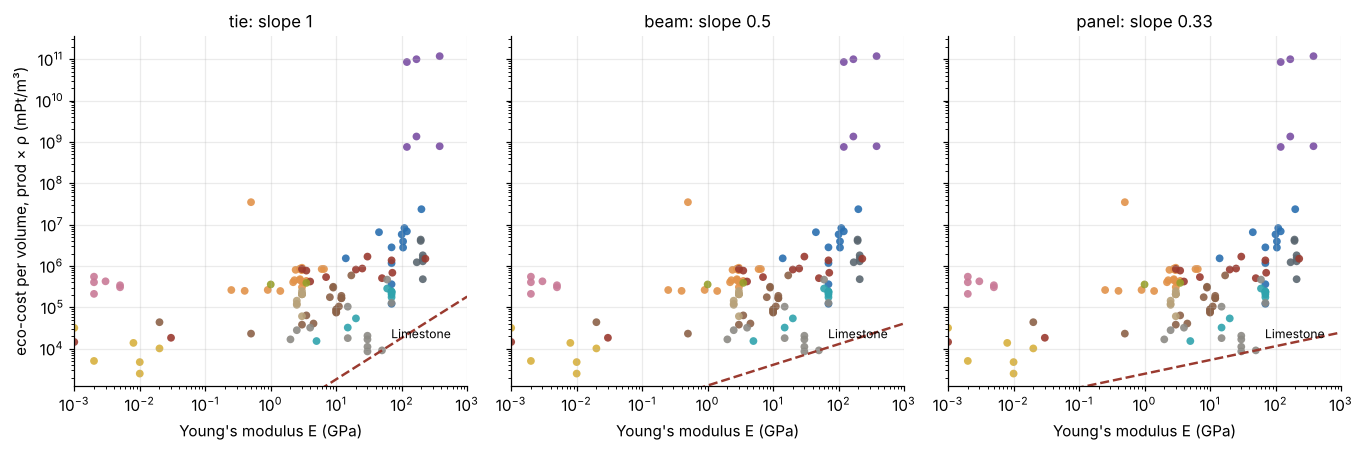

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.2), sharey=True)
for ax, (a, nm) in zip(axs, [(1, "tie"), (1/2, "beam"), (1/3, "panel")]):
    for f in FAMILIES:
        g = eng[eng.family == f]
        ax.scatter(g["E"], g["eco_V"], s=26, color=PAL[f], edgecolor="none", alpha=.9)
    best = eng.loc[eng[f"I_{nm}"].idxmin()]
    xs = np.array([1e-3, 1e3]); ax.plot(xs, best["eco_V"] * (xs / best["E"])**a, "--", color="#9A3A2F", lw=1.6)
    ax.annotate(best["name"], (best["E"], best["eco_V"]), xytext=(6, 8), textcoords="offset points", fontsize=8)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(1e-3, 1e3); ax.set_ylim(eng["eco_V"].min() / 2, eng["eco_V"].max() * 3)
    ax.set_xlabel("Young's modulus E (GPa)"); ax.set_title(f"{nm}: slope {a:.2g}")
axs[0].set_ylabel("eco-cost per volume, prod × ρ (mPt/m³)")
plt.tight_layout(); plt.show()

The lightest-impact materials sit at **low eco-cost per volume and high stiffness**, in the lower right. The winner changes with the loading case,
exactly as on the price-based chart. Two things are worth noticing: (i) the cheapest-to-produce stiff solids are mineral (concrete, brick,
limestone) and wood, (ii) metals and composites need to be much stiffer *per unit of eco-cost* to compete.

Everything above uses only two axes at a time. The VAE below uses all the indicators together.

## 3 · A variational autoencoder for eco-profiles

**Inputs.** For every material in the engineering set we use five numbers, all standardised after a log transform where the quantity is positive:

`log₁₀ prod · log₁₀ waste · rec_gain · log₁₀ ρ · log₁₀ E`

Waste treatment is missing for some rows and recycling gain for most, so the loss and the encoder are **masked**: the encoder receives
`[x·m, m]` (values with missing entries zeroed, plus the mask) and the reconstruction error only counts observed entries.
During training we also randomly hide features (*feature dropout*), which teaches the encoder to cope with whatever subset is
available for a new material.

**Objective** (β-VAE, per sample, with unit-variance Gaussian likelihood):

$$ \mathcal L \;=\; \underbrace{\sum_j m_j\,(x_j-\hat x_j)^2}_{\text{masked reconstruction}} \;+\; \beta\;\underbrace{\tfrac12\sum_k\big(\mu_k^2+\sigma_k^2-\log\sigma_k^2-1\big)}_{\mathrm{KL}\left(q(z|x)\,\|\,\mathcal N(0,I)\right)} $$

Small β gives a sharp but "memorising" map, large β a smooth but blurry one; β ≥ 4 collapses to the prior (nothing is learned).
We keep a **2-D latent space** so that it can be drawn.

In [8]:
FEATS = ["log_prod", "log_waste", "rec_gain", "log_rho", "log_E"]
NICE = ["log10 production (mPt/kg)", "log10 waste (mPt/kg)", "recycling gain", "log10 density (kg/m3)", "log10 modulus (GPa)"]

def features(df):
    X = np.column_stack([np.log10(df["prod"]), np.log10(df["waste"]), df["rec_gain"], np.log10(df["rho"]), np.log10(df["E"])]).astype(np.float32)
    return X

X_eng = features(eng)
M_eng = ~np.isnan(X_eng)
mu_f = np.nanmean(X_eng, 0); sd_f = np.nanstd(X_eng, 0)          # statistics of the observed entries
print("observed per feature:", dict(zip(FEATS, M_eng.sum(0))), "of", len(eng))

def standardise(X, M): return np.where(M, (X - mu_f) / sd_f, 0).astype(np.float32)
Z_eng = standardise(X_eng, M_eng)

class VAE(nn.Module):
    def __init__(self, d=5, h=(32, 16), z=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(2 * d, h[0]), nn.Tanh(), nn.Linear(h[0], h[1]), nn.Tanh())
        self.mu, self.lv = nn.Linear(h[1], z), nn.Linear(h[1], z)
        self.dec = nn.Sequential(nn.Linear(z, h[1]), nn.Tanh(), nn.Linear(h[1], h[0]), nn.Tanh(), nn.Linear(h[0], d))
    def encode(self, x, m):
        h = self.enc(torch.cat([x * m, m], 1)); return self.mu(h), self.lv(h).clamp(-8, 4)
    def forward(self, x, m):
        mu, lv = self.encode(x, m)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.dec(z), mu, lv

def feature_dropout(M, gen):
    # hide the mechanical block (rho, E) together 25 % of the time, waste / recycling gain independently 20 %
    keep = torch.ones_like(M)
    keep[:, 3:5] *= (torch.rand(M.shape[0], 1, generator=gen) > .25).float()
    keep[:, 1:3] *= (torch.rand(M.shape[0], 2, generator=gen) > .20).float()
    return M * keep

def train_vae(Zs, Ms, beta, seed=0, epochs=3000, lr=1e-2, augment=True):
    torch.manual_seed(seed); gen = torch.Generator().manual_seed(seed)
    x = torch.tensor(Zs); m = torch.tensor(Ms.astype(np.float32))
    net = VAE(); opt = torch.optim.Adam(net.parameters(), lr); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    hist = []
    for ep in range(epochs):
        b = beta * min(1, ep / (0.3 * epochs))                    # KL warm-up
        m_in = feature_dropout(m, gen) if augment else m
        rec, mu, lv = net(x, m_in)
        rl = (((rec - x) ** 2) * m).sum() / x.shape[0]            # loss counts every observed entry, even hidden ones
        kl = (-0.5 * (1 + lv - mu ** 2 - lv.exp()).sum(1)).mean()
        loss = rl + b * kl
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if ep % 20 == 0: hist.append((ep, rl.item(), kl.item()))
    net.eval(); return net, np.array(hist)

BETAS = [0.05, 0.2, 0.5, 1.0, 2.0]
models, hists = {}, {}
for b in BETAS:
    models[b], hists[b] = train_vae(Z_eng, M_eng, b)
    print(f"beta={b:<4} final reconstruction {hists[b][-1,1]:.2f}  KL {hists[b][-1,2]:.2f}")

observed per feature: {'log_prod': np.int64(118), 'log_waste': np.int64(84), 'rec_gain': np.int64(18), 'log_rho': np.int64(118), 'log_E': np.int64(118)} of 118


beta=0.05 final reconstruction 0.24  KL 4.18


beta=0.2  final reconstruction 0.42  KL 2.70


beta=0.5  final reconstruction 0.64  KL 1.92


beta=1.0  final reconstruction 1.05  KL 1.23


beta=2.0  final reconstruction 2.14  KL 0.58


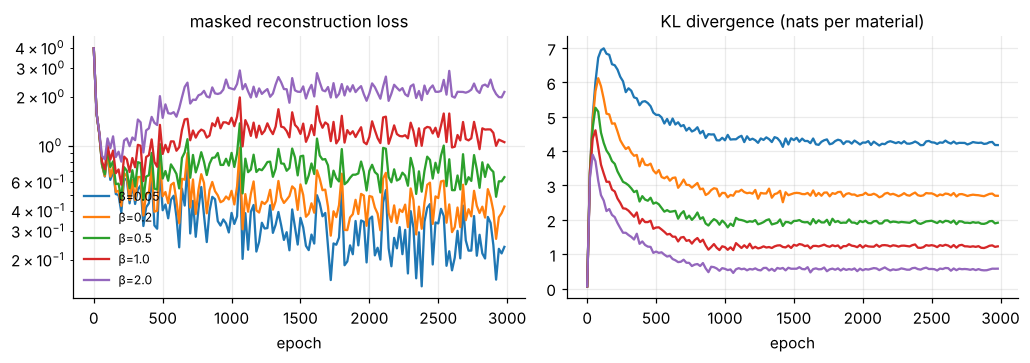

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.4))
for b in BETAS:
    axs[0].plot(hists[b][:, 0], hists[b][:, 1], label=f"β={b}"); axs[1].plot(hists[b][:, 0], hists[b][:, 2])
axs[0].set_yscale("log"); axs[0].set_title("masked reconstruction loss"); axs[1].set_title("KL divergence (nats per material)")
axs[0].legend(fontsize=8, frameon=False); [a.set_xlabel("epoch") for a in axs]
plt.tight_layout(); plt.show()

The classic β trade-off: a small β lets the code carry about 4 nats per material (a near-perfect reconstruction of 118 points), a large β throws
information away. The **default β = 0.5** used in the article is a compromise between a map that separates the families and a smooth decoder.

### The latent map

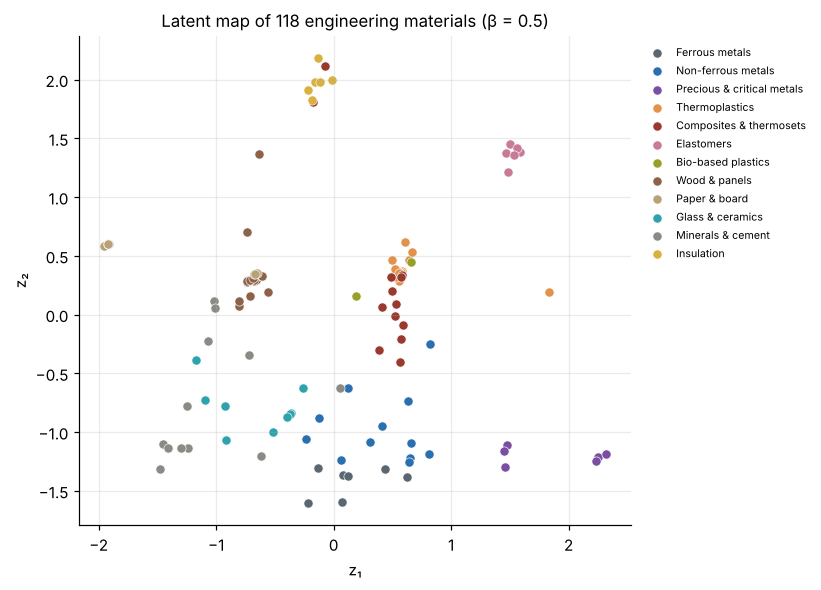

In [10]:
BETA = 0.5
net = models[BETA]
def embed(net, X, M):
    with torch.no_grad():
        mu, lv = net.encode(torch.tensor(standardise(X, M)), torch.tensor(M.astype(np.float32)))
    return mu.numpy()
def decode(net, z):
    with torch.no_grad():
        return net.dec(torch.as_tensor(z, dtype=torch.float32)).numpy() * sd_f + mu_f     # back to natural log units

Z2 = embed(net, X_eng, M_eng)
eng["z1"], eng["z2"] = Z2[:, 0], Z2[:, 1]
fig, ax = plt.subplots(figsize=(7.2, 6))
for f in FAMILIES:
    g = eng[eng.family == f]
    if len(g): ax.scatter(g.z1, g.z2, s=36, color=PAL[f], label=f, edgecolor="white", lw=.4)
ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left"); ax.set_aspect("equal")
ax.set_xlabel("z₁"); ax.set_ylabel("z₂"); ax.set_title(f"Latent map of {len(eng)} engineering materials (β = {BETA})")
plt.tight_layout(); plt.show()

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
fam = eng["family"].values
acc = cross_val_score(KNeighborsClassifier(3), Z2, fam, cv=LeaveOneOut()).mean()
base = pd.Series(fam).value_counts(normalize=True).iloc[0]
print(f"Leave-one-out 3-NN family accuracy in the 2-D latent space: {acc:.2f}   (always guessing the biggest family: {base:.2f})")

Leave-one-out 3-NN family accuracy in the 2-D latent space: 0.76   (always guessing the biggest family: 0.16)


The VAE was never told which family a material belongs to, yet neighbours on the map are usually from the same family: the latent space has
organised itself around the *eco-profile + stiffness-density* signature.

### The decoder as a continuous surface

Because the decoder is a smooth function `ẑ → (prod, waste, rec. gain, ρ, E)`, every property becomes a **continuous field** over the map (no
more gaps between the points). That is the same idea as the continuous gradient of E/ρ in the *Ashby's Maps, Renewed* article.

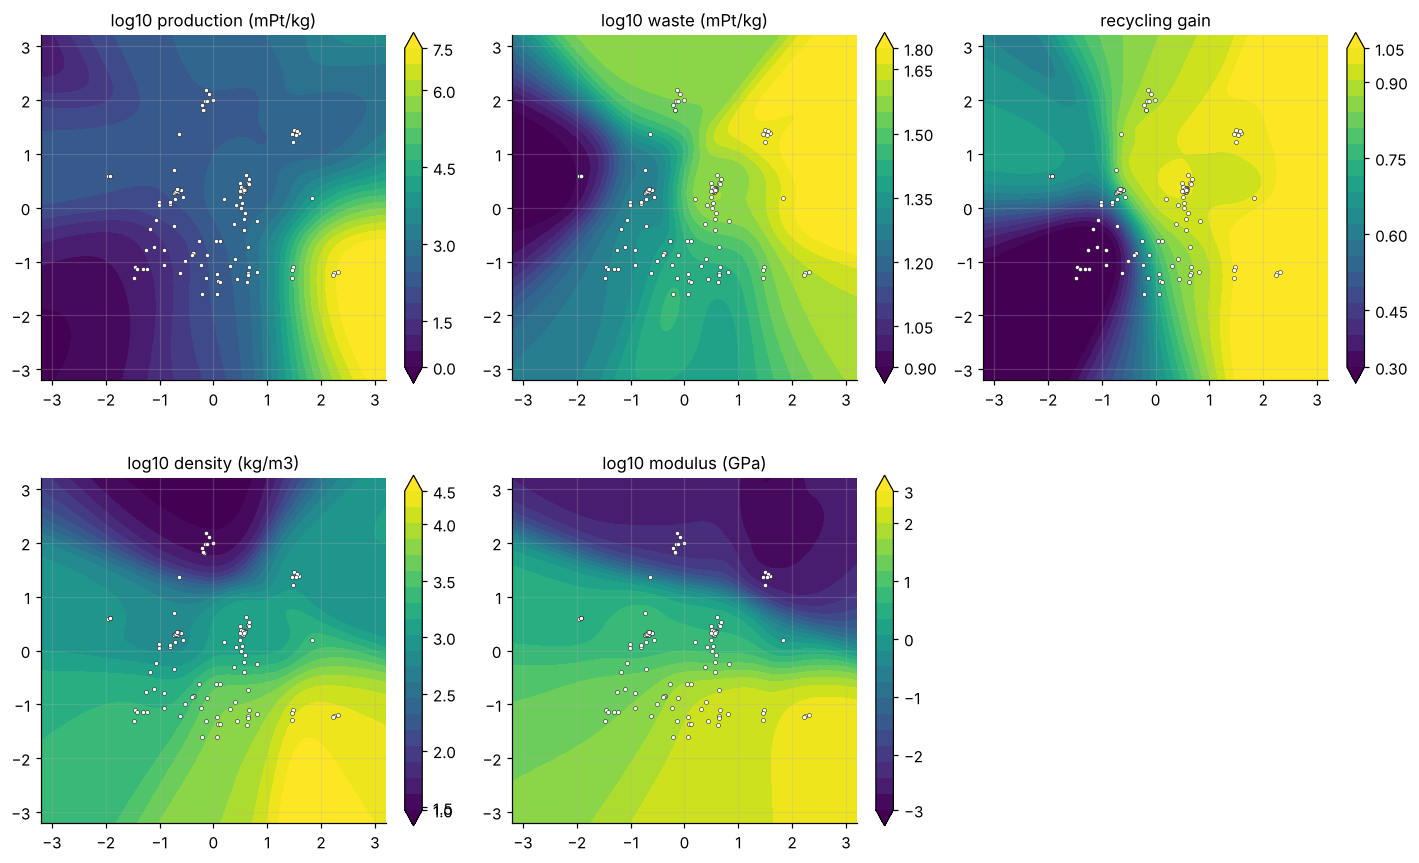

In [12]:
g = np.linspace(-3.2, 3.2, 161); GX, GY = np.meshgrid(g, g)
D = decode(net, np.c_[GX.ravel(), GY.ravel()]).reshape(161, 161, 5)
lim = dict(zip(FEATS, [(np.nanpercentile(X_eng[:, j], 1), np.nanpercentile(X_eng[:, j], 99)) for j in range(5)]))
fig, axs = plt.subplots(2, 3, figsize=(13, 8.2))
for j, ax in zip(range(5), axs.ravel()):
    lo, hi = lim[FEATS[j]]
    cs = ax.contourf(GX, GY, D[:, :, j], levels=np.linspace(lo, hi, 21), cmap="viridis", extend="both")
    ax.scatter(Z2[:, 0], Z2[:, 1], s=7, color="white", edgecolor="k", lw=.3)
    ax.set_title(NICE[j]); ax.set_aspect("equal"); plt.colorbar(cs, ax=ax, fraction=.046, ticks=MaxNLocator(6))
axs.ravel()[5].axis("off")
plt.tight_layout(); plt.show()

Reading the five panels: production impact (top left) is highest in the lower right, where the platinum-group metals sit, and lowest in the
lower left, the mineral corner; waste treatment varies only between about 9 and 40 mPt/kg; recycling gain is high on the right (metals, plastics)
and low on the left (glass, minerals); density is lowest at the top (insulation foams) and modulus is lowest in the upper right (elastomers). Density and modulus
vary along different directions, which is why a 2-D map can separate "stiff and heavy" from "soft and light".

### Eco-Ashby on the map: contours of an index

For each point of the map the decoder gives `prod, ρ, E`, so we can evaluate the index $I_a=\mathrm{prod}\cdot\rho/E^{a}$ **everywhere** and draw its contours.

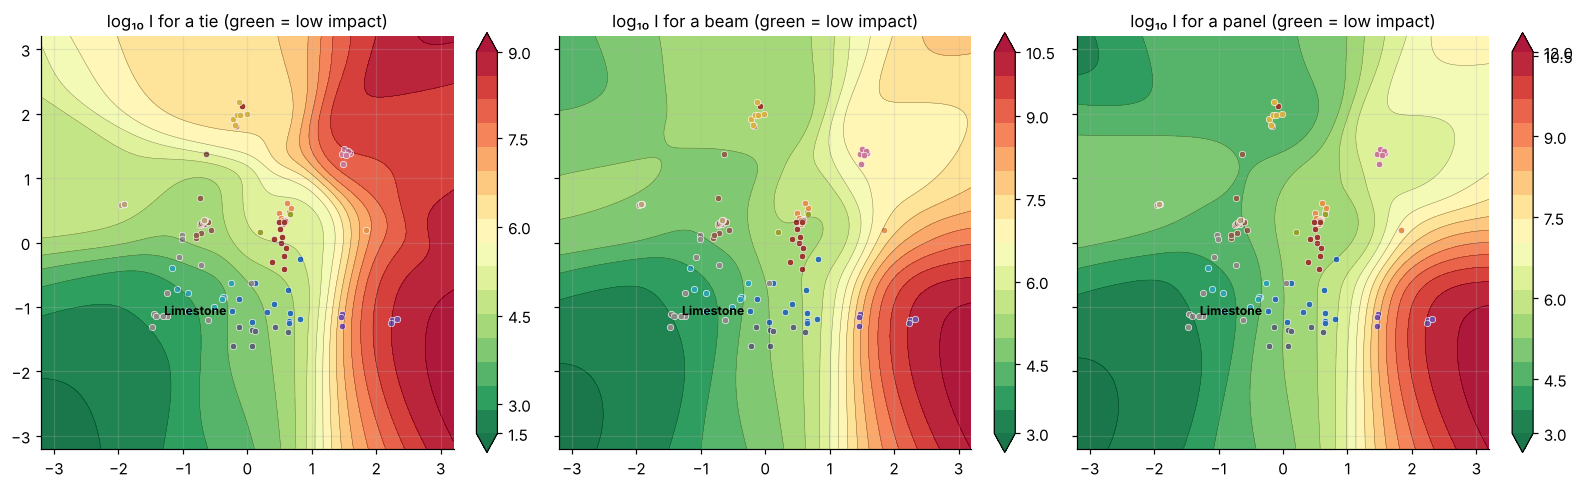

In [13]:
def log_index(x, a):          # x in log10 units: [prod, waste, gain, rho, E]
    return x[..., 0] + x[..., 3] - a * x[..., 4]

fig, axs = plt.subplots(1, 3, figsize=(14.5, 4.9), sharey=True)
for ax, (a, nm) in zip(axs, [(1, "tie"), (1/2, "beam"), (1/3, "panel")]):
    L = log_index(D, a)
    lv = np.linspace(np.nanpercentile(L, 2), np.nanpercentile(L, 98), 17)
    cs = ax.contourf(GX, GY, L, levels=lv, cmap="RdYlGn_r", extend="both", alpha=.9)
    ax.contour(GX, GY, L, levels=lv, colors="k", linewidths=.3, alpha=.5)
    for f in FAMILIES:
        gg = eng[eng.family == f]
        if len(gg): ax.scatter(gg.z1, gg.z2, s=18, color=PAL[f], edgecolor="white", lw=.4)
    tv = log_index(np.c_[np.log10(eng["prod"]), 0 * eng["prod"], 0 * eng["prod"], np.log10(eng["rho"]), np.log10(eng["E"])], a)
    b = eng.iloc[int(np.argmin(tv))]; ax.annotate(b["name"], (b.z1, b.z2), xytext=(8, 8), textcoords="offset points", fontsize=8, fontweight="bold")
    ax.set_title(f"log₁₀ I for a {nm} (green = low impact)"); ax.set_aspect("equal"); plt.colorbar(cs, ax=ax, fraction=.046, ticks=MaxNLocator(6))
plt.tight_layout(); plt.show()

### Gradient search in latent space

We can now **walk downhill** on the index: start from any material, compute the gradient of `log₁₀ I` through the decoder (automatic differentiation)
and move the latent point. A small *prior penalty* `λ‖z‖²` keeps the walk inside the region the VAE has seen: without it the search escapes to
fictitious "materials" that no data supports.

$$ z_{t+1} \;=\; z_t \;-\; \eta\,\nabla_z\Big[\log_{10} I_a\big(\mathrm{dec}(z)\big)\;+\;\lambda\,\|z\|^2\Big] $$

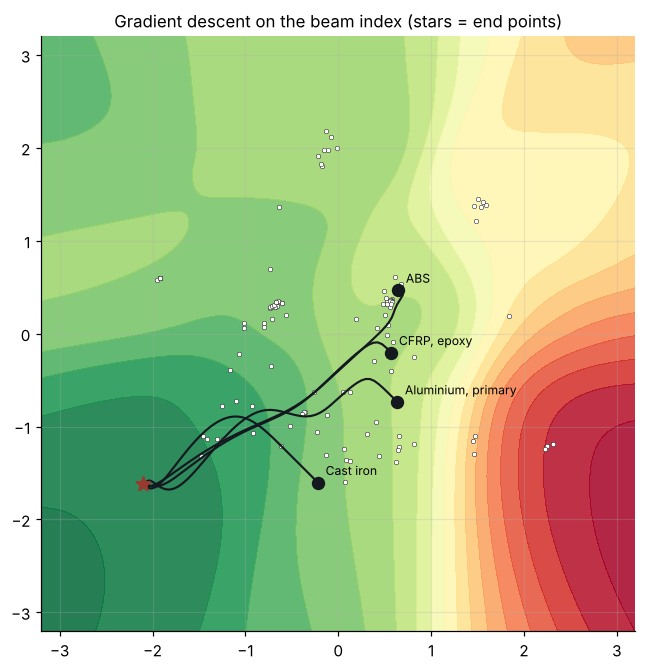

,start,prod,rho,E,index_start,index_end,nearest_real
0,Cast iron,5.7,2266.300049,25.700001,57439.1,2556.6,"(Limestone, 0.69)"
1,"Aluminium, primary",5.7,2266.300049,25.700001,299225.4,2556.6,"(Limestone, 0.69)"
2,ABS,5.7,2266.300049,25.700001,272581.8,2556.6,"(Limestone, 0.69)"
3,"CFRP, epoxy",5.7,2266.300049,25.700001,231312.8,2556.6,"(Limestone, 0.69)"


In [14]:
def descend(net, z0, a, lam=0.05, steps=250, lr=0.05):
    z = torch.tensor(np.asarray(z0, dtype=np.float32), requires_grad=True); opt = torch.optim.Adam([z], lr)
    path = [z.detach().numpy().copy()]
    for _ in range(steps):
        x = net.dec(z) * torch.tensor(sd_f) + torch.tensor(mu_f)
        loss = log_index(x, a) + lam * (z ** 2).sum()
        opt.zero_grad(); loss.backward(); opt.step(); path.append(z.detach().numpy().copy())
    return np.array(path)

def nearest(z, k=3):
    d = np.linalg.norm(Z2 - z, axis=1); i = np.argsort(d)[:k]; return [(eng.name.iloc[j], round(float(d[j]), 2)) for j in i]

starts = ["Cast iron", "Aluminium, primary", "ABS", "CFRP, epoxy"]
a, nm = 1/2, "beam"
fig, ax = plt.subplots(figsize=(7.4, 6.2))
L = log_index(D, a); lv = np.linspace(np.nanpercentile(L, 2), np.nanpercentile(L, 98), 17)
ax.contourf(GX, GY, L, levels=lv, cmap="RdYlGn_r", extend="both", alpha=.85)
ax.scatter(Z2[:, 0], Z2[:, 1], s=9, color="white", edgecolor="k", lw=.3)
rows = []
for s in starts:
    z0 = eng.loc[eng.name == s, ["z1", "z2"]].values[0]
    P = descend(net, z0, a); ax.plot(P[:, 0], P[:, 1], "-", color="#14181F", lw=1.4); ax.scatter(*P[0], s=60, color="#14181F", zorder=5)
    ax.annotate(s, P[0], xytext=(5, 5), textcoords="offset points", fontsize=8); ax.scatter(*P[-1], s=90, marker="*", color="#9A3A2F", zorder=6)
    x = decode(net, P[-1]); rows.append(dict(start=s, prod=10**x[0], rho=10**x[3], E=10**x[4], index_start=10**float(log_index(decode(net, P[0]), a)), index_end=10**float(log_index(x, a)), nearest_real=nearest(P[-1], 1)[0]))
ax.set_aspect("equal"); ax.set_title("Gradient descent on the beam index (stars = end points)")
plt.tight_layout(); plt.show()
pd.DataFrame(rows).round(1)

Every path, whatever the starting material, converges to the same point: a **very low production impact (about 6 mPt/kg) with a density near 2 300 kg/m³ and a modulus around 25 GPa**,
which is the signature of the mineral and concrete corner (the nearest real entry is limestone). That is a plausible design direction for a *stiffness-limited, mass-insensitive* part
(*"look at minerals, concrete and wood before metals and carbon composites"*), but the end point is **a synthetic eco-profile, not a recipe**: it tells you which region of eco-profile space to explore, nothing more.
Note also that this index ignores mass-critical applications and durability; a beam in an aircraft would never be made of limestone.

## 4 · What can the VAE not do? (honest evaluation)

We hide the density and modulus of a random 25 % of the materials, train on the rest, and ask the decoder to **impute** them from the
eco-profile alone. Baseline: the (log) mean of the training materials.

In [15]:
def imputation_test(beta, reps=4, epochs=1500):
    rng = np.random.default_rng(7); has = np.where(M_eng[:, 3] & M_eng[:, 4])[0]; out = []
    for r in range(reps):
        test = rng.choice(has, size=len(has) // 4, replace=False)
        Mtr = M_eng.copy(); Mtr[test, 3:5] = False
        net_r, _ = train_vae(standardise(X_eng, Mtr), Mtr, beta, seed=r, epochs=epochs)
        z = embed(net_r, X_eng, Mtr)[test]
        pred = decode(net_r, z)[:, 3:5]; true = X_eng[test, 3:5]
        base = np.nanmean(np.where(Mtr[:, 3:5], X_eng[:, 3:5], np.nan), 0)
        fam_mean = np.array([[np.nanmean(np.where(Mtr[:, j] & (fam == fam[t]), X_eng[:, j], np.nan)) if (Mtr[:, j] & (fam == fam[t])).any() else base[j - 3]
                              for j in (3, 4)] for t in test])
        out.append([np.sqrt(((pred - true) ** 2).mean(0)), np.sqrt(((base - true) ** 2).mean(0)), np.sqrt(((fam_mean - true) ** 2).mean(0))])
    o = np.mean(out, 0); return o
res = []
for b in [0.2, 0.5, 1.0]:
    o = imputation_test(b); res.append(dict(beta=b, VAE_rho=o[0, 0], mean_rho=o[1, 0], family_mean_rho=o[2, 0], VAE_E=o[0, 1], mean_E=o[1, 1], family_mean_E=o[2, 1]))
pd.DataFrame(res).round(2).set_index("beta")

,VAE_rho,mean_rho,family_mean_rho,VAE_E,mean_E,family_mean_E
beta,,,,,,
0.2,0.46,0.61,0.27,1.03,1.39,0.68
0.5,0.50,0.61,0.27,1.10,1.39,0.68
1.0,0.53,0.61,0.27,1.17,1.39,0.68


RMSE is in decades (log₁₀ units). Reading: the VAE improves on guessing the global mean (by roughly 15–25 %), but the remaining error is large (about 0.5 decades on density
and 1 decade on modulus), and a rule that merely knows the *family* is far better (0.27 and 0.68 decades). The VAE was not given the family, and the production indicator per kg says very little about stiffness:
the **eco-profile alone does not identify the mechanical properties**. This is a useful warning for the course:

* the low in-sample reconstruction error at small β is **memorisation**, not understanding;
* the latent map is a good *visualisation and interpolation* device (families cluster; contours of an index are smooth), but a poor *prediction* device for missing mechanical properties;
* real design use would need richer inputs (measured properties, uncertainty, the Ecolizer's own "grey" less-trustworthy flags) before trusting any gradient search.

The Ecolizer itself warns that *"these numbers have a relatively high uncertainty. Small differences between scores for two products must be treated with particular care"*, and our density and modulus are rounded typical values. Treat every number on the map accordingly.

## 5 · Materials without ρ and E: encode them anyway

The Ecolizer contains many entries for which stiffness is meaningless (chemicals, glues, paints, raw sands...). They were not used for training, but the masked encoder
can still place them on the map from their production indicator (and waste value) alone.

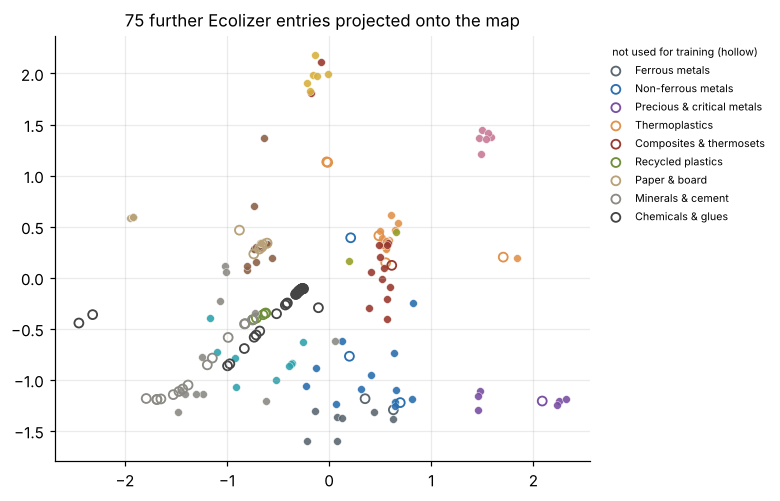

In [16]:
extra = mat[~mat.index.isin(eng.index)].copy()
extra["rec_gain"] = (-extra["rec_total"] / extra["prod"]).clip(0, 1)
X_ext = features(extra); M_ext = ~np.isnan(X_ext)
Zx = embed(net, X_ext, M_ext); extra["z1"], extra["z2"] = Zx[:, 0], Zx[:, 1]
fig, ax = plt.subplots(figsize=(7.2, 6))
for f in FAMILIES:
    g = eng[eng.family == f]; ax.scatter(g.z1, g.z2, s=26, color=PAL[f], edgecolor="white", lw=.3, alpha=.9)
    h = extra[extra.family == f]; ax.scatter(h.z1, h.z2, s=34, facecolor="none", edgecolor=PAL[f], lw=1.2, label=f if len(h) else None)
ax.set_aspect("equal"); ax.legend(fontsize=7, frameon=False, title="not used for training (hollow)", title_fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title(f"{len(extra)} further Ecolizer entries projected onto the map"); plt.tight_layout(); plt.show()

## 6 · Export for the interactive article

The Distill article decodes the VAE **in the browser**. We therefore export, for every β, the decoder weights (a 2→16→32→5 network with `tanh`),
the standardisation constants and the 2-D coordinates of every material.

In [17]:
def lin(layer): return {"W": layer.weight.detach().numpy().round(5).tolist(), "b": layer.bias.detach().numpy().round(5).tolist()}
allm = pd.concat([eng.assign(trained=1), extra.assign(trained=0)]).sort_index()
X_all = features(allm); M_all = ~np.isnan(X_all)
out = {"features": FEATS, "mu": mu_f.round(5).tolist(), "sd": sd_f.round(5).tolist(), "families": FAMILIES, "palette": PAL, "betas": BETAS, "default_beta": BETA, "models": {}}
for b in BETAS:
    n = models[b]; Zb = embed(n, X_all, M_all)
    out["models"][str(b)] = {"dec": [lin(n.dec[0]), lin(n.dec[2]), lin(n.dec[4])], "z": Zb.round(4).tolist(),
                             "final_rec": float(hists[b][-1, 1]), "final_kl": float(hists[b][-1, 2])}
def nn_(v): return None if pd.isna(v) else float(v)
out["materials"] = [dict(name=r["name"], family=r["family"], sub=r["subfamily"], page=int(r["page"]), prod=nn_(r["prod"]), waste=nn_(r["waste"]),
                         rec_proc=nn_(r["rec_proc"]), rec_total=nn_(r["rec_total"]), gain=nn_(r["rec_gain"]), rho=nn_(r["rho"]), E=nn_(r["E"]),
                         trained=int(r["trained"]), conv=(None if pd.isna(r["unit_conversion"]) else r["unit_conversion"])) for _, r in allm.iterrows()]
with open(f"{EXPORT}/vae_data.json", "w") as f: json.dump(out, f, separators=(",", ":"))
ex = {"processes": pd.read_csv(f"{DATA}/ecolizer_processes.csv").where(lambda d: d.notna(), None).to_dict("records"),
      "energy": pd.read_csv(f"{DATA}/ecolizer_energy_transport.csv").to_dict("records")}
with open(f"{EXPORT}/explorer_data.json", "w") as f: json.dump(ex, f, separators=(",", ":"))
print({k: os.path.getsize(f"{EXPORT}/{k}") // 1024 for k in ["vae_data.json", "explorer_data.json"]}, "kB")

{'vae_data.json': 154, 'explorer_data.json': 39} kB


## 7 · Exercises for the course

1. **Weighting.** The ReCiPe weights are 400/400/200 for health/ecosystems/resources. Why does a different weighting change the *ranking* of lead, aluminium and wood but hardly the ranking of platinum?
2. **Functional unit.** Use `ecolizer_energy_transport.csv` to compare two designs of the same part: 1 kg of primary aluminium transported 500 km by lorry, versus 1.8 kg of glass-filled PA made in France-electricity-heavy conditions. What is the break-even mass?
3. **Closing the loop.** For the 21 materials with a recycling block, which have the smallest `rec_gain`? What does that tell you about when design-for-recycling is worth the effort?
4. **β.** Re-train with β = 0.05 and β = 2 and redo the family-accuracy test. Which is better for a *map*, which for *interpolation*?
5. **Break the gradient search.** Set `lam = 0` in `descend`. Where do the paths end up, and are they near any real material? Explain why this matters when a student proposes "the optimiser says we need a material with ρ = 400 and E = 80 GPa".
6. **Extend.** Add the missing σ_y for the metals and polymers and reproduce the I_σ eco-indices of the lecture on the map.